# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [17]:
# Import the library
import cv2
import numpy as np
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt
import matplotlib.cm as cm

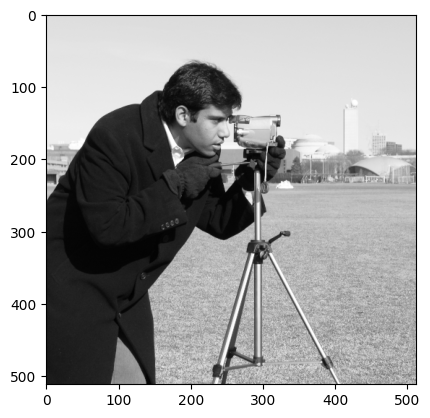

In [18]:
# ── Load image ────────────────────────────────────
image1 = data.camera()
plt.imshow(image1, cmap = cm.Greys_r)
plt.show()


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [24]:
# Get the size of the image
width, height = image1.size
print(f"Original size: {width}x{height}")

# scaling factors
scale_factor = 2

Original size: 512x512


In [25]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
new_size = (width * scale_factor, height * scale_factor)
resized_image = image1.resize(new_size, Image.LANCZOS)


Original size: 512x512
New size: (1024, 1024)


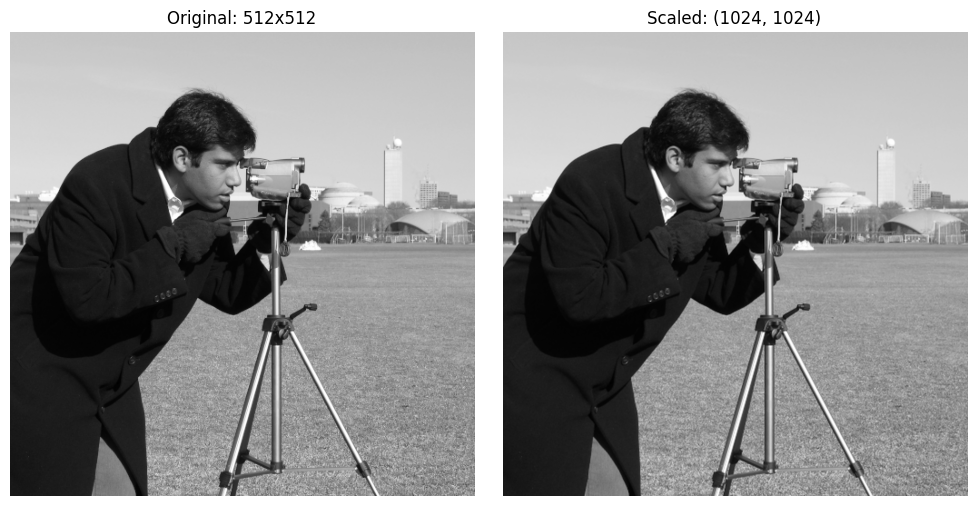

In [43]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
resized_image.save("task1_1_scaled.jpg")
print(f"Original size: {width}x{height}")
print(f"New size: {resized_image.size}")
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image1, cmap='gray')
axes[0].set_title(f"Original: {width}x{height}")
axes[0].axis('off')

axes[1].imshow(resized_image, cmap='gray')
axes[1].set_title(f"Scaled: {resized_image.size}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [28]:

cx, cy = 2, 1
new_size_nonuniform = (int(width * cx), int(height * cy))



In [29]:
stretched_image = image1.resize(new_size_nonuniform, Image.LANCZOS)
stretched_image.save("task1_2_stretched.jpg")

Stretched size: (1024, 512)


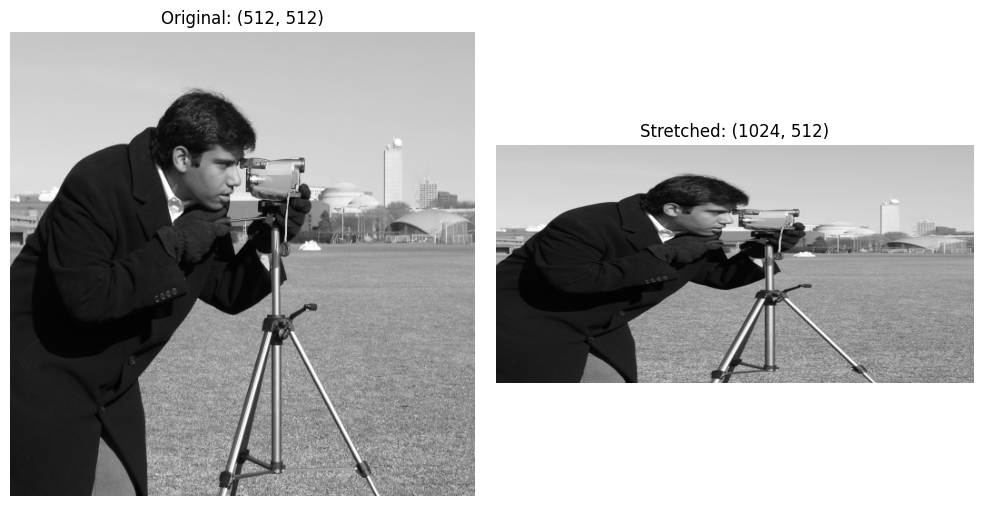

In [44]:
print(f"Stretched size: {stretched_image.size}")
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image1, cmap='gray')
axes[0].set_title(f"Original: {image1.size}")
axes[0].axis('off')

axes[1].imshow(stretched_image, cmap='gray')
axes[1].set_title(f"Stretched: {stretched_image.size}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [31]:
# ── 2. Rotate 120 degrees ──────────────────────────


rotated_image = image1.rotate(120, expand=True)

# Save the rotated image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_image.save("task1_2_rotated.jpg")
print(f"Original size: {image1.size}")
print(f"Rotated size: {rotated_image.size}")

Original size: (512, 512)
Rotated size: (700, 700)


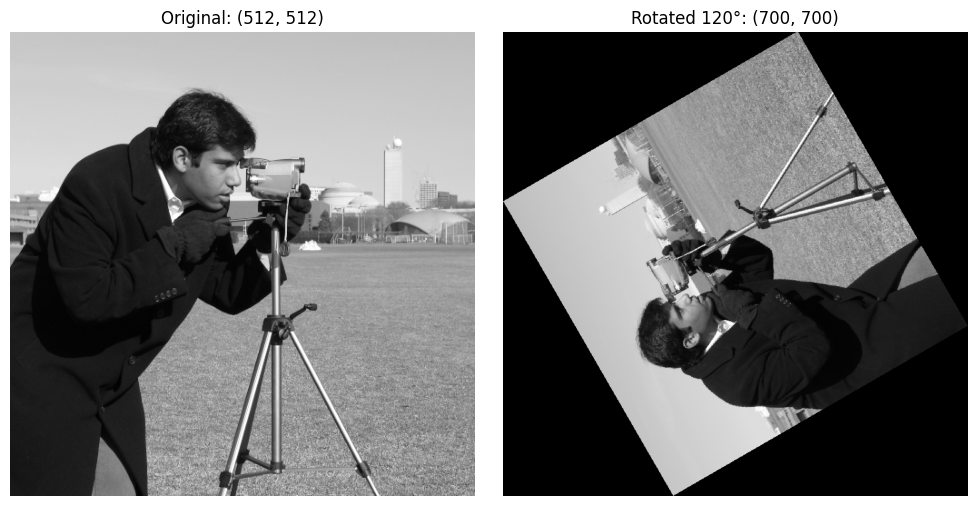

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image1, cmap='gray')
axes[0].set_title(f"Original: {image1.size}")
axes[0].axis('off')

axes[1].imshow(rotated_image, cmap='gray')
axes[1].set_title(f"Rotated 120°: {rotated_image.size}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 3. Shear

In [33]:
# -- c. Get the image dimensions ────────────────────

width, height = image1.size
print(f"Original size: {width}x{height}")

Original size: 512x512


In [34]:
# -- d. define the shear matrix ────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.

shear_factor = 0.5  # try X-axis shear first

# Affine matrix for X-axis shear
shx = shear_factor
shy = 0
tx = 0
ty = 0

In [35]:
# -- e. Apply the shear transformation to the image ────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

# Adjust output size to accommodate the shear (avoid cropping)
new_width = int(width + abs(shx) * height)

sheared_image = image1.transform(
    (new_width, height),
    Image.AFFINE,
    (1, shx, tx, shy, 1, ty),
    resample=Image.BICUBIC
)

Original size: 512x512
Sheared size: (768, 512)


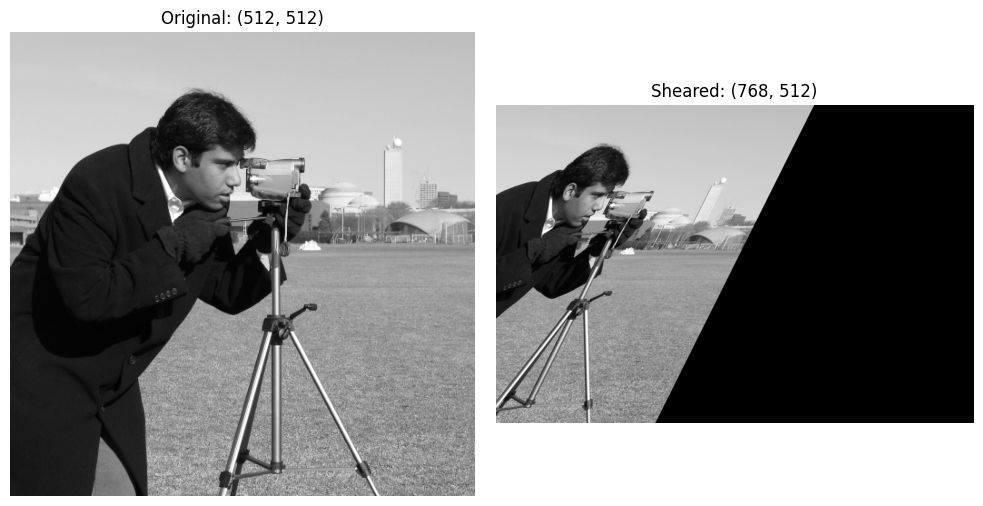

In [37]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_image.save("task1_3_sheared.jpg")
print(f"Original size: {width}x{height}")
print(f"Sheared size: {sheared_image.size}")
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image1, cmap='gray')
axes[0].set_title(f"Original: {image1.size}")
axes[0].axis('off')

axes[1].imshow(sheared_image, cmap='gray')
axes[1].set_title(f"Sheared: {sheared_image.size}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

In [38]:
# ── 1. Negative ──────────────────────────────────
# Method 1: NumPy array manipulation

arr = np.array(image1)
negative_arr = 255 - arr
negative_image_np = Image.fromarray(negative_arr.astype(np.uint8))

negative_image_np.save("task2_1_negative_numpy.jpg")
print(f"Negative (NumPy) size: {negative_image_np.size}")




Negative (NumPy) size: (512, 512)


In [39]:
# Method 2: PIL's ImageOps
from PIL import ImageOps

negative_image_pil = ImageOps.invert(image1.convert('L'))

negative_image_pil.save("task2_1_negative_pil.jpg")
print(f"Negative (PIL) size: {negative_image_pil.size}")

Negative (PIL) size: (512, 512)


In [40]:
# ── 2. Log transformation ────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

arr = np.array(image1).astype(np.float64)  # convert to float BEFORE log to avoid casting issues
c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
log_transformed_arr = c * np.log(1 + arr)
log_transformed_arr = np.clip(log_transformed_arr, 0, 255).astype(np.uint8)  # clip before casting to uint8

log_transformed_image = Image.fromarray(log_transformed_arr)
log_transformed_image.save("task2_2_log.jpg")
print(f"Log-transformed size: {log_transformed_image.size}")

Log-transformed size: (512, 512)


In [41]:
# ── 3. Power-law / Gamma correction ──────────────

arr = np.array(image1).astype(np.float64) / 255.0  # normalize to [0, 1]

gamma = 0.5  # try values <1 to brighten, >1 to darken

gamma_corrected_arr = np.power(arr, gamma)
gamma_corrected_arr = (gamma_corrected_arr * 255).astype(np.uint8)

gamma_corrected_image = Image.fromarray(gamma_corrected_arr)
gamma_corrected_image.save("task2_3_gamma.jpg")
print(f"Gamma-corrected size: {gamma_corrected_image.size}")


Gamma-corrected size: (512, 512)


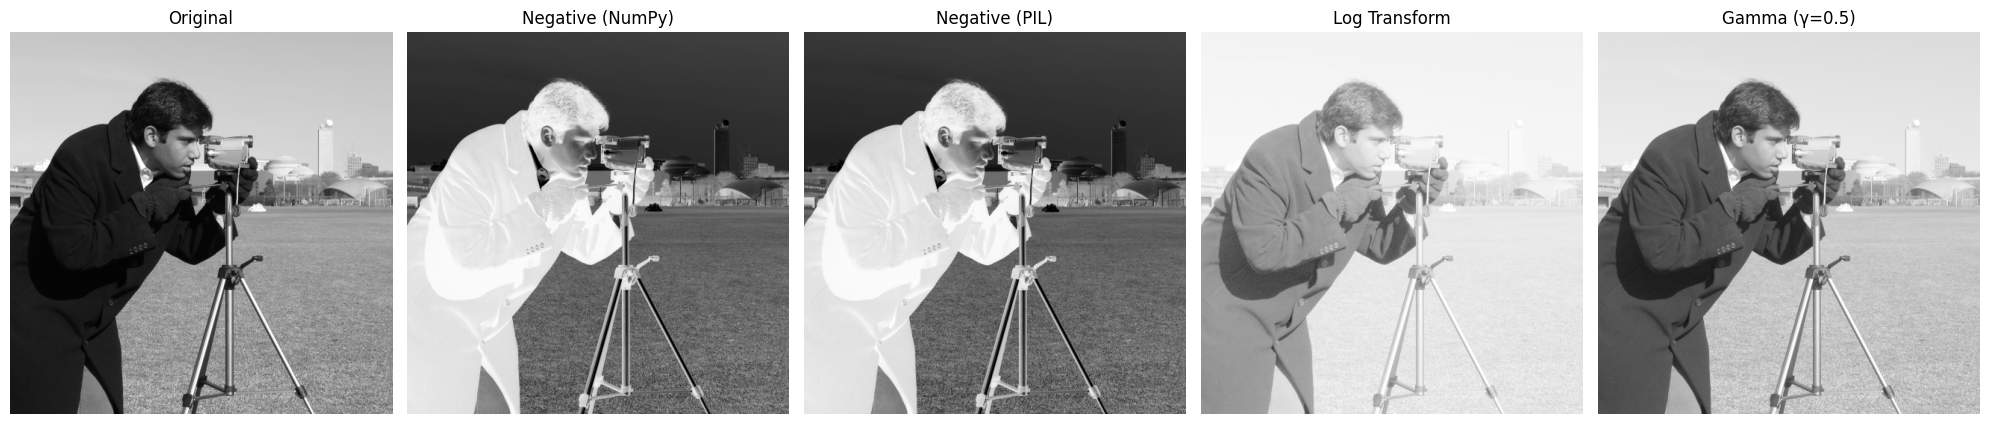

In [42]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

axes[0].imshow(image1, cmap='gray')
axes[0].set_title(f"Original")
axes[0].axis('off')

axes[1].imshow(negative_image_np, cmap='gray')
axes[1].set_title(f"Negative (NumPy)")
axes[1].axis('off')

axes[2].imshow(negative_image_pil, cmap='gray')
axes[2].set_title(f"Negative (PIL)")
axes[2].axis('off')

axes[3].imshow(log_transformed_image, cmap='gray')
axes[3].set_title(f"Log Transform")
axes[3].axis('off')

axes[4].imshow(gamma_corrected_image, cmap='gray')
axes[4].set_title(f"Gamma (γ={gamma})")
axes[4].axis('off')

plt.tight_layout()
plt.show()